## Dataset REVIEWS
[Kaggle Link](https://www.kaggle.com/competitions/184-702-tu-ml-2025-w-reviews/overview)

### Imports

todo in code: remove ifs i did while debugging, clean code, document ig? -> create the docs

In [39]:
import os
import sys
import pandas as pd

# Add the parent directory to sys.path to be able to import own packages from outside the notebooks directory
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

# some helper functions (see src directory for details)
from src.utils import *
from src.evaluation import *


In [40]:
# Load the data and catch a quick glimpse.
curr_dir = os.getcwd()

# Load the given training and test data sets
train_path = os.path.join(curr_dir, '..', 'data', 'reviews/amazon_review_ID.shuf.lrn.csv')
#test_path = os.path.join(curr_dir, '..', 'data', 'reviews/amazon_review_ID.shuf.tes.csv')

train_df = pd.read_csv(train_path)
#final_test_df = pd.read_csv(test_path)

train_df.shape#, test_df.shape

(750, 10002)

In [41]:
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif, chi2, SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.cross_decomposition import PLSRegression

In [42]:
target_column = 'Class'
X, y = train_df.drop(columns=[target_column]), train_df[target_column]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
kfold_cv = KFold(n_splits=10, shuffle=True, random_state=42)

Numeric feature balance:
              mean         std  min    max      skew
ID      374.500000  216.650640  0.0  749.0  0.000000
V1       11.612000    5.424576  0.0   32.0  0.564004
V2        7.317333    3.521150  0.0   19.0  0.395602
V3        6.724000    3.330457  0.0   20.0  0.469128
V4        6.385333    3.698164  0.0   20.0  0.691829
...            ...         ...  ...    ...       ...
V9996     0.225333    0.504874  0.0    3.0  2.448257
V9997     0.190667    0.458905  0.0    3.0  2.653711
V9998     0.208000    0.489614  0.0    4.0  2.819564
V9999     0.208000    0.470139  0.0    3.0  2.292388
V10000    0.216000    0.581201  0.0    4.0  3.371778

[10001 rows x 5 columns]

Categorical: Class
Class
Sherwin        0.027
Chachra        0.025
Wilson         0.025
Power          0.025
Comdet         0.025
Davisson       0.024
Merritt        0.024
Chell          0.024
Hayes          0.024
Brody          0.023
Chandler       0.023
Corn           0.021
Cholette       0.021
Blankenship   

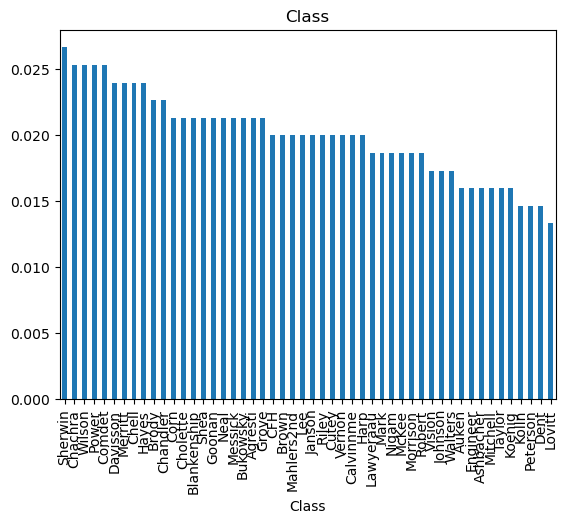

In [43]:
def check_feature_balance(df, bins=20):
    num_cols = df.select_dtypes(include=['number']).columns
    cat_cols = df.select_dtypes(include=['object', 'category']).columns

    print("Numeric feature balance:")
    print(df[num_cols].agg(['mean','std','min','max','skew']).T)
    
    for col in cat_cols:
        print(f"\nCategorical: {col}")
        print(df[col].value_counts(normalize=True).round(3))
        df[col].value_counts(normalize=True).plot(kind='bar', title=col)
        plt.show()
check_feature_balance(train_df)

In [44]:
feature_ranges = train_df.drop(columns=[target_column]).max() - train_df.drop(columns=[target_column]).min()

# Sort and inspect
feature_ranges.sort_values(ascending=False)

ID       749
V6567    362
V6568    174
V6569    120
V6570    112
        ... 
V6286      1
V6284      1
V6283      1
V6282      1
V5000      1
Length: 10001, dtype: int64

TODO FOR DOCS:

- each classifier show multiple results, not just the best  - show results with different  hyper param in each category, do 2-3 runs with best in A, the 3 random in B etc...
- evaluate the performance
    - here use the best modell
    - compare the 4 measures (acc recall prec ..)
    - how can i improve the results? feature selection, some kinda better scaluing?
    - which algo works well for the given dataset, why?
    - Compare holdout to cross-validation, maybe try different train/split sizes
    - run time
- create some kinda table/figure whith all the data collected


KNN

Fast, not much 'learning'

Feature Selection:

SelectKBest preffered, feature selection based on statisctical tests

Pros: Extremely Fast

Cons: It tests each feature in isolation.



=== Running GridSearch for SelectKBest (mutual_info) ===
Fitting 10 folds for each of 40 candidates, totalling 400 fits


c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [2344 2916 3112 3293] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Done SelectKBest search.
Best CV score: 0.4583333333333333
Best params: {'knn__n_neighbors': 7, 'scaler': StandardScaler(), 'selector__k': 200}

=== Running GridSearch for SelectFromModel(RandomForest) ===
Fitting 10 folds for each of 8 candidates, totalling 80 fits
Done SelectFromModel(RF) search.
Best CV score: 0.10333333333333335
Best params: {'knn__n_neighbors': 3, 'scaler': StandardScaler()}

=== Running GridSearch for Passthrough (no selection) ===
Fitting 10 folds for each of 8 candidates, totalling 80 fits
Done passthrough search.
Best CV score: 0.07500000000000001
Best params: {'knn__n_neighbors': 3, 'scaler': 'passthrough'}

--- SelectKBest_mutual_info Summary ---
Best CV score: 0.4583333333333333
Best params: {'knn__n_neighbors': 7, 'scaler': StandardScaler(), 'selector__k': 200}

Best CV accuracy per scaler:
      scaler_name  mean_test_score
0  StandardScaler         0.458333
1     passthrough         0.208333


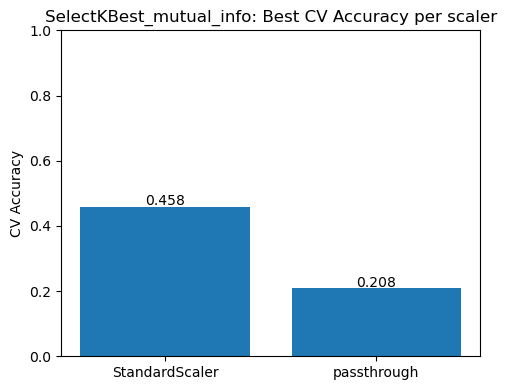

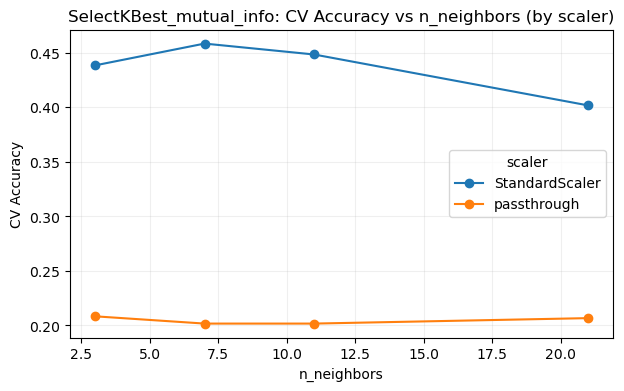


Top CV configurations (head):
 mean_test_score     param_scaler  param_knn__n_neighbors  param_selector__k
        0.458333 StandardScaler()                       7                200
        0.455000 StandardScaler()                       7                100
        0.448333 StandardScaler()                      11                100
        0.438333 StandardScaler()                       3                200
        0.436667 StandardScaler()                       3                100
        0.425000 StandardScaler()                      11                200
        0.408333 StandardScaler()                       7                300
        0.405000 StandardScaler()                       7                 50
        0.403333 StandardScaler()                       3                300
        0.401667 StandardScaler()                      21                100

Selected feature count for best pipeline (if available): 200

--- SelectFromModel_RF Summary ---
Best CV score: 0.1033333

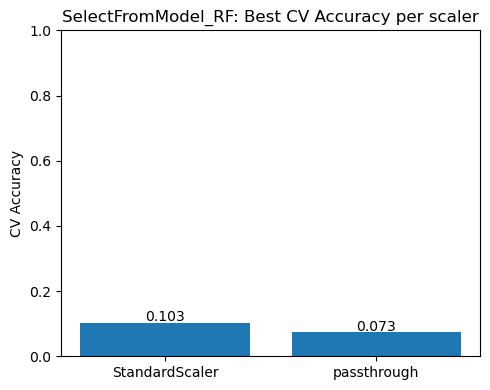

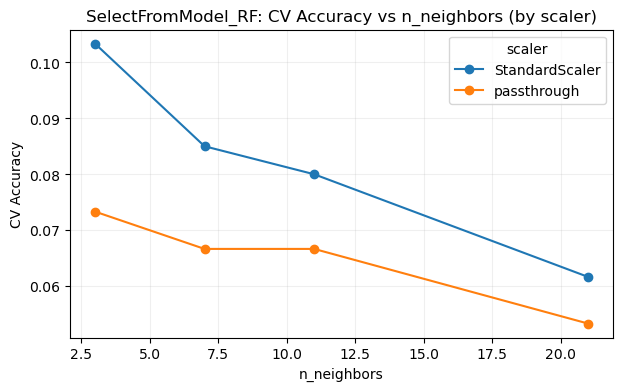


Top CV configurations (head):
 mean_test_score     param_scaler  param_knn__n_neighbors
        0.103333 StandardScaler()                       3
        0.085000 StandardScaler()                       7
        0.080000 StandardScaler()                      11
        0.073333      passthrough                       3
        0.066667      passthrough                       7
        0.066667      passthrough                      11
        0.061667 StandardScaler()                      21
        0.053333      passthrough                      21

Selected feature count for best pipeline (if available): 5001

--- Passthrough Summary ---
Best CV score: 0.07500000000000001
Best params: {'knn__n_neighbors': 3, 'scaler': 'passthrough'}

Best CV accuracy per scaler:
      scaler_name  mean_test_score
1     passthrough         0.075000
0  StandardScaler         0.043333


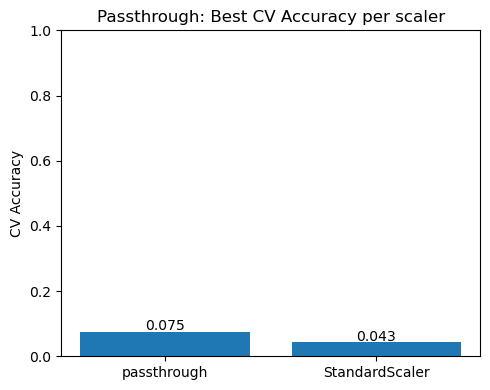

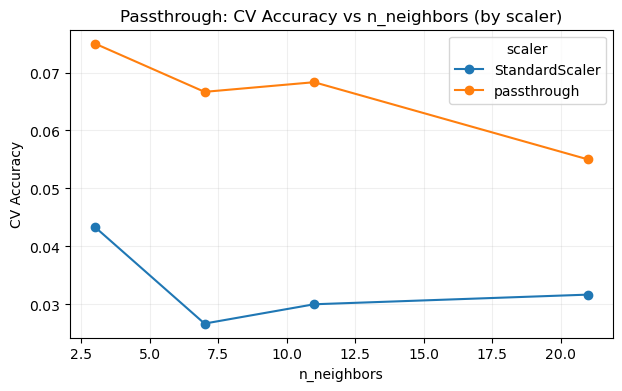


Top CV configurations (head):
 mean_test_score     param_scaler  param_knn__n_neighbors
        0.075000      passthrough                       3
        0.068333      passthrough                      11
        0.066667      passthrough                       7
        0.055000      passthrough                      21
        0.043333 StandardScaler()                       3
        0.031667 StandardScaler()                      21
        0.030000 StandardScaler()                      11
        0.026667 StandardScaler()                       7

Selected feature count for best pipeline (if available): 10001


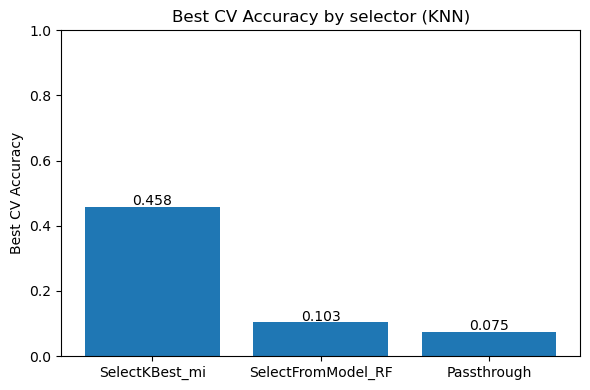


=== Test set evaluation for SelectKBest_mi ===


c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


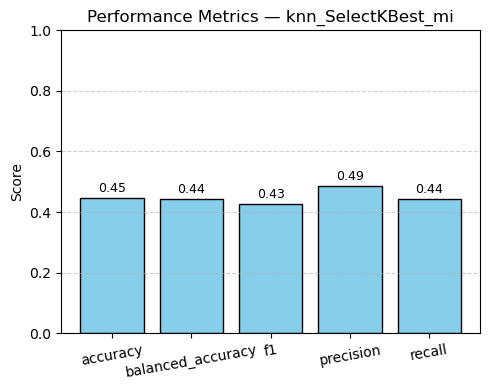


=== Test set evaluation for SelectFromModel_RF ===


c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


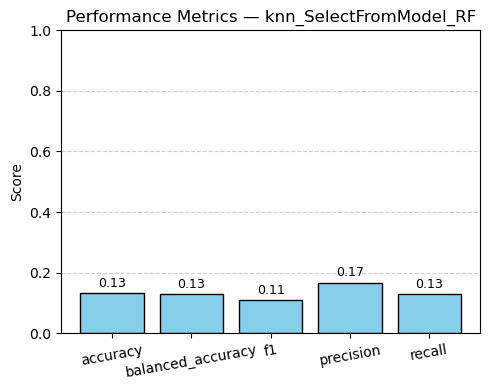


=== Test set evaluation for Passthrough ===


c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


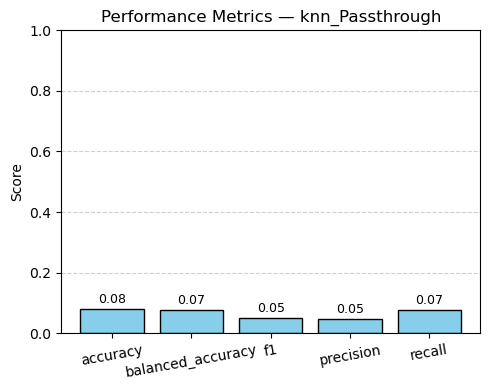

In [50]:
# --- Separate pipelines per selector: run & plot results separately ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, SelectFromModel
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.base import clone

# ---------- 1) Pipeline: SelectKBest(mutual_info) ----------
pipeline_skb = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(f_classif)),
    ('knn', KNeighborsClassifier())
])

param_grid_skb = {
    'scaler': [StandardScaler(), 'passthrough'],
    'selector__k': [50, 100, 200, 300, 400],
    'knn__n_neighbors': [3, 7, 11, 21]
}

print("\n=== Running GridSearch for SelectKBest (mutual_info) ===")
grid_skb = GridSearchCV(pipeline_skb, param_grid_skb, cv=kfold_cv,
                        scoring='accuracy', n_jobs=-1, verbose=1, return_train_score=False)
grid_skb.fit(X_train, y_train)
print("Done SelectKBest search.")
print("Best CV score:", grid_skb.best_score_)
print("Best params:", grid_skb.best_params_)

# ---------- 2) Pipeline: SelectFromModel(RandomForest) ----------
# keep moderate n_estimators for runtime; increase if you have time
rf_for_sel = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)
pipeline_sfm = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectFromModel(estimator=rf_for_sel, threshold='median')),
    ('knn', KNeighborsClassifier())
])

param_grid_sfm = {
    'scaler': [StandardScaler(), 'passthrough'],
    'knn__n_neighbors': [3, 7, 11, 21]
}

print("\n=== Running GridSearch for SelectFromModel(RandomForest) ===")
grid_sfm = GridSearchCV(pipeline_sfm, param_grid_sfm, cv=kfold_cv,
                        scoring='accuracy', n_jobs=-1, verbose=1, return_train_score=False)
grid_sfm.fit(X_train, y_train)
print("Done SelectFromModel(RF) search.")
print("Best CV score:", grid_sfm.best_score_)
print("Best params:", grid_sfm.best_params_)

# ---------- 3) Pipeline: passthrough (no selection) ----------
pipeline_passthrough = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', 'passthrough'),
    ('knn', KNeighborsClassifier())
])

param_grid_pass = {
    'scaler': [StandardScaler(), 'passthrough'],
    'knn__n_neighbors': [3, 7, 11, 21]
}

print("\n=== Running GridSearch for Passthrough (no selection) ===")
grid_pass = GridSearchCV(pipeline_passthrough, param_grid_pass, cv=kfold_cv,
                         scoring='accuracy', n_jobs=-1, verbose=1, return_train_score=False)
grid_pass.fit(X_train, y_train)
print("Done passthrough search.")
print("Best CV score:", grid_pass.best_score_)
print("Best params:", grid_pass.best_params_)

# ---------- Helper for readable scaler name ----------
def scaler_name(x):
    if isinstance(x, str):
        return x
    try:
        return x.__class__.__name__
    except Exception:
        return str(x)

# ---------- Function to analyze a fitted GridSearchCV object ----------
def analyze_grid(grid, title_prefix=''):
    cv = pd.DataFrame(grid.cv_results_)
    # add readable scaler column
    cv['scaler_name'] = cv['param_scaler'].apply(scaler_name)
    # add n_neighbors if present
    if 'param_knn__n_neighbors' in cv.columns:
        cv['n_neighbors'] = pd.to_numeric(cv['param_knn__n_neighbors'], errors='coerce').astype('Int64')
    else:
        cv['n_neighbors'] = np.nan

    # Summaries
    best_score = grid.best_score_
    best_params = grid.best_params_
    print(f"\n--- {title_prefix} Summary ---")
    print("Best CV score:", best_score)
    print("Best params:", best_params)

    # 1) Best CV accuracy per scaler
    best_per_scaler = cv.groupby('scaler_name')['mean_test_score'].max().reset_index().sort_values('mean_test_score', ascending=False)
    print("\nBest CV accuracy per scaler:")
    print(best_per_scaler)

    plt.figure(figsize=(5,4))
    plt.bar(best_per_scaler['scaler_name'], best_per_scaler['mean_test_score'])
    plt.ylim(0,1)
    plt.ylabel('CV Accuracy')
    plt.title(f'{title_prefix}: Best CV Accuracy per scaler')
    for i, v in enumerate(best_per_scaler['mean_test_score']):
        plt.text(i, v + 0.005, f"{v:.3f}", ha='center')
    plt.tight_layout()
    plt.show()

    # 2) Accuracy vs n_neighbors (if present)
    if cv['n_neighbors'].notna().any():
        agg = cv.groupby(['scaler_name', 'n_neighbors'])['mean_test_score'].max().unstack('scaler_name')
        plt.figure(figsize=(7,4))
        for col in agg.columns:
            plt.plot(agg.index.astype(float), agg[col], marker='o', label=col)
        plt.xlabel('n_neighbors')
        plt.ylabel('CV Accuracy')
        plt.title(f'{title_prefix}: CV Accuracy vs n_neighbors (by scaler)')
        plt.legend(title='scaler')
        plt.grid(alpha=0.2)
        plt.show()
    else:
        print("No n_neighbors variation found in cv results for this grid.")

    # 3) Show top configurations
    top = cv.sort_values('mean_test_score', ascending=False).head(10)
    cols_show = ['mean_test_score', 'param_scaler', 'param_knn__n_neighbors']
    # some grids have selector__k
    if 'param_selector__k' in cv.columns:
        cols_show.append('param_selector__k')
    print("\nTop CV configurations (head):")
    print(top[cols_show].to_string(index=False))

    # 4) For the best estimator (GridSearchCV refitted), report selected feature count if selector has get_support
    best_pipe = grid.best_estimator_
    sel = best_pipe.named_steps.get('selector', None)
    sel_count = None
    try:
        if sel == 'passthrough' or sel is None:
            sel_count = X_train.shape[1]
        elif hasattr(sel, 'get_support'):
            sel_mask = sel.get_support()
            sel_count = int(sel_mask.sum())
        elif hasattr(sel, 'n_features_'):
            sel_count = int(sel.n_features_)
    except Exception:
        sel_count = None
    print(f"\nSelected feature count for best pipeline (if available): {sel_count}")


    return cv, best_pipe

# ---------- Analyze each grid separately ----------
cv_skb, best_pipe_skb = analyze_grid(grid_skb, title_prefix='SelectKBest_mutual_info')
cv_sfm, best_pipe_sfm = analyze_grid(grid_sfm, title_prefix='SelectFromModel_RF')
cv_pass, best_pipe_pass = analyze_grid(grid_pass, title_prefix='Passthrough')

# ---------- Optional: Combined comparison bar chart (best CV per selector) ----------
best_scores = pd.DataFrame({
    'selector': ['SelectKBest_mi', 'SelectFromModel_RF', 'Passthrough'],
    'best_cv': [grid_skb.best_score_, grid_sfm.best_score_, grid_pass.best_score_]
}).sort_values('best_cv', ascending=False)

plt.figure(figsize=(6,4))
plt.bar(best_scores['selector'], best_scores['best_cv'])
plt.ylim(0,1)
plt.ylabel('Best CV Accuracy')
plt.title('Best CV Accuracy by selector (KNN)')
for i, v in enumerate(best_scores['best_cv']):
    plt.text(i, v + 0.005, f"{v:.3f}", ha='center')
plt.tight_layout()
plt.show()

# ---------- Final test-evaluations for each best pipeline ----------
for name, best_pipe in [('SelectKBest_mi', best_pipe_skb), ('SelectFromModel_RF', best_pipe_sfm), ('Passthrough', best_pipe_pass)]:
    y_pred = best_pipe.predict(X_test)
    print(f"\n=== Test set evaluation for {name} ===")
    eval_res = evaluate_run(name=f'knn_{name}', y_true=y_test, y_pred=y_pred, task_type='classification')
    plot_metrics(eval_res, figsize=(5,4), x_rotation=10)
    # from sklearn.metrics import classification_report
    # print(classification_report(y_test, y_pred))



--- Starting KNN Search (with scaler choices) ---
Fitting 10 folds for each of 40 candidates, totalling 400 fits


c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
80 fits failed out of a total of 400.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
80 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\lenar\anaconda3\envs\Machinelearning\L

KNN search complete.

--- Best KNN Model (all params) ---
Best Score (CV Accuracy): 0.4583
Best Parameters:
{'knn__n_neighbors': 7, 'scaler': StandardScaler(), 'selector__k': 200}

Best CV accuracy per scaler:
      scaler_name  mean_test_score
0  StandardScaler         0.458333
1     passthrough         0.208333


c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [2344 2916 3112 3293] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


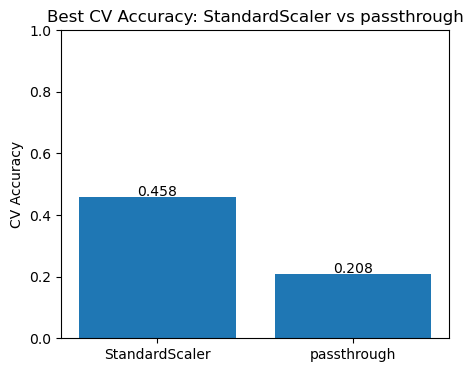

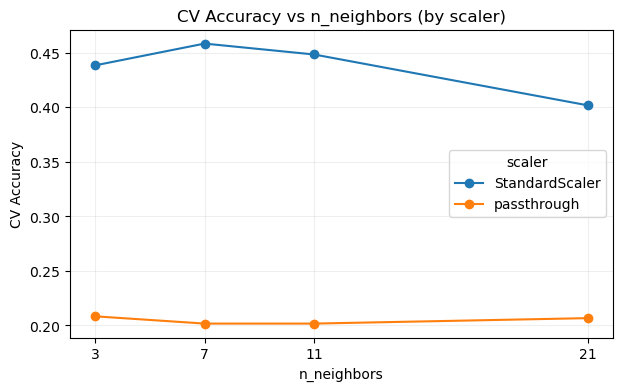

c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


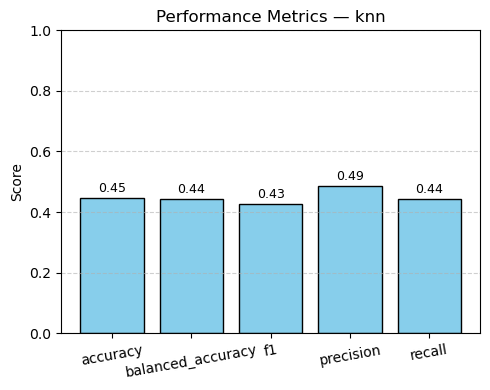

In [52]:
# Use of best feature selection method + different scalers
# ---------- Pipeline: KNN with scaler choice + SelectKBest(f_classif) ----------
pipeline_knn = Pipeline([
    ('scaler', StandardScaler()), # will be overridden by param_grid with 'passthrough'
    ('selector', SelectKBest(f_classif)),
    ('knn', KNeighborsClassifier())
])


param_grid_knn = {
    'scaler': [StandardScaler(), 'passthrough'],   # compare scaling vs no scaling
    'selector__k': ['none', 50, 100, 200, 300],
    'knn__n_neighbors': [3, 7, 11, 21]
}

print("\n--- Starting KNN Search (with scaler choices) ---")
grid_knn = GridSearchCV(pipeline_knn, param_grid_knn, cv=kfold_cv,
                        scoring='accuracy', n_jobs=-1, verbose=1, return_train_score=False)
grid_knn.fit(X_train, y_train)
print("KNN search complete.\n")

# print best overall
print("--- Best KNN Model (all params) ---")
print(f"Best Score (CV Accuracy): {grid_knn.best_score_:.4f}")
print("Best Parameters:")
print(grid_knn.best_params_)

# === extract cv results into a DataFrame for analysis ===
cv = pd.DataFrame(grid_knn.cv_results_)

# helper to normalize scaler name (estimator objects => class name; 'passthrough' left as-is)
def scaler_name(x):
    if isinstance(x, str):
        return x
    try:
        return x.__class__.__name__
    except Exception:
        return str(x)

cv['scaler_name'] = cv['param_scaler'].apply(scaler_name)
cv['n_neighbors'] = cv['param_knn__n_neighbors'].astype(int)
cv['selector__k'] = cv['param_selector__k']
# 1) Best (max) CV accuracy achieved for each scaler (across other hyperparams)
best_per_scaler = cv.groupby('scaler_name')['mean_test_score'].max().reset_index()
print("\nBest CV accuracy per scaler:")
print(best_per_scaler)

# 2) A cleaner comparison: best accuracy per scaler (bar plot)
plt.figure(figsize=(5,4))
plt.bar(best_per_scaler['scaler_name'], best_per_scaler['mean_test_score'])
plt.ylim(0,1)
plt.ylabel('CV Accuracy')
plt.title('Best CV Accuracy: StandardScaler vs passthrough')
for i, v in enumerate(best_per_scaler['mean_test_score']):
    plt.text(i, v + 0.005, f"{v:.3f}", ha='center')
plt.show()

# 3) More detailed: how mean CV accuracy varies with n_neighbors for each scaler
agg = cv.groupby(['scaler_name', 'n_neighbors'])['mean_test_score'].max().unstack('scaler_name')

plt.figure(figsize=(7,4))
for col in agg.columns:
    plt.plot(agg.index, agg[col], marker='o', label=col)
plt.xticks(agg.index)
plt.xlabel('n_neighbors')
plt.ylabel('CV Accuracy')
plt.title('CV Accuracy vs n_neighbors (by scaler)')
plt.legend(title='scaler')
plt.grid(alpha=0.2)
plt.show()

# === final test-evaluation using the overall best estimator ===
best_knn = grid_knn.best_estimator_
y_pred_knn = best_knn.predict(X_test)

evaluation = evaluate_run(name='knn', y_true=y_test, y_pred=y_pred_knn, task_type='classification')
plot_metrics(evaluation, figsize=(5,4), x_rotation=10)
#print(classification_report(y_test, y_pred_knn))


SVM

Feature selection

SelectKBest(f_classif) -> fast
selector_estimator = LinearSVC (l1, l2) -> too slow, didnt finish



=== Running GridSearch for SelectKBest (f_classif) ===
Fitting 10 folds for each of 9 candidates, totalling 90 fits


c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [2344 2916 3112 3293] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Done SelectKBest search.
Best CV score: 0.625
Best params: {'scaler': StandardScaler(), 'selector__k': 200, 'svm__C': 0.1, 'svm__kernel': 'linear'}

=== Running GridSearch for SelectFromModel(RandomForest) ===
Fitting 10 folds for each of 3 candidates, totalling 30 fits
Done SelectFromModel(RF) search.
Best CV score: 0.5866666666666667
Best params: {'scaler': StandardScaler(), 'svm__C': 0.1, 'svm__kernel': 'linear'}

=== Running GridSearch for Passthrough (no selection) ===
Fitting 10 folds for each of 3 candidates, totalling 30 fits
Done passthrough search.
Best CV score: 0.5066666666666666
Best params: {'scaler': StandardScaler(), 'svm__C': 0.1, 'svm__kernel': 'linear'}

Top 10 CV configurations for SelectKBest_f_classif:
 mean_test_score     param_scaler  param_selector__k  param_svm__C param_svm__kernel
        0.625000 StandardScaler()                200           0.1            linear
        0.625000 StandardScaler()                200           1.0            linear
        0.6

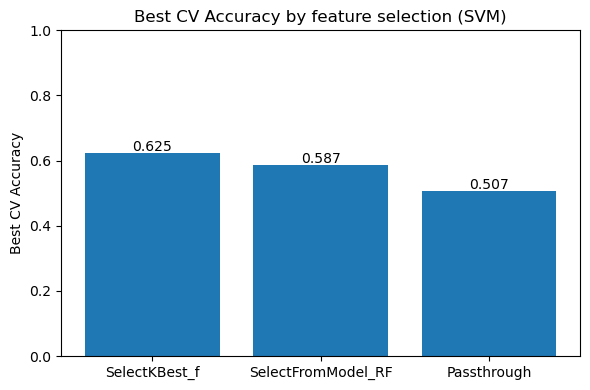


=== Test set evaluation for SelectKBest_f ===


c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


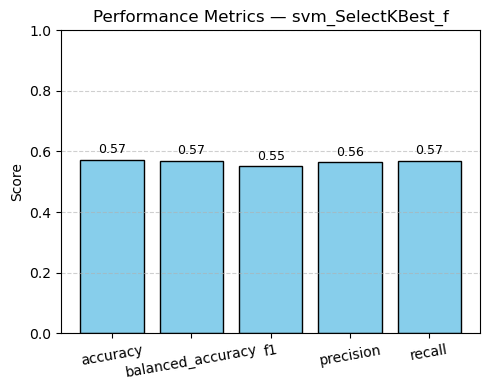

              precision    recall  f1-score   support

     Agresti       0.67      0.67      0.67         3
   Ashbacher       0.50      0.50      0.50         2
       Auken       0.00      0.00      0.00         2
 Blankenship       1.00      1.00      1.00         3
       Brody       0.00      0.00      0.00         3
       Brown       0.33      0.67      0.44         3
    Bukowsky       0.33      0.33      0.33         3
         CFH       0.67      0.67      0.67         3
   Calvinnme       0.00      0.00      0.00         3
     Chachra       0.75      0.75      0.75         4
    Chandler       0.33      0.67      0.44         3
       Chell       0.25      0.25      0.25         4
    Cholette       1.00      0.67      0.80         3
      Comdet       1.00      0.75      0.86         4
        Corn       0.50      0.67      0.57         3
       Cutey       0.67      0.67      0.67         3
    Davisson       0.33      0.50      0.40         4
        Dent       1.00    

c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c


=== Test set evaluation for SelectFromModel_RF ===


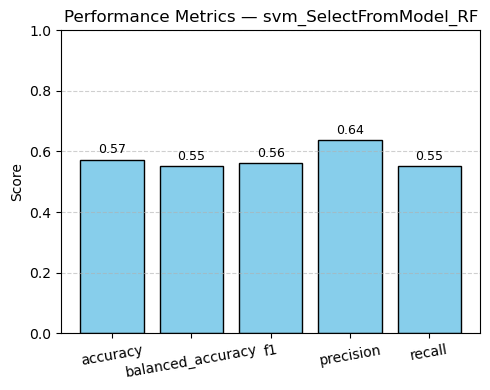

              precision    recall  f1-score   support

     Agresti       0.75      1.00      0.86         3
   Ashbacher       1.00      0.50      0.67         2
       Auken       0.00      0.00      0.00         2
 Blankenship       1.00      1.00      1.00         3
       Brody       0.50      0.33      0.40         3
       Brown       0.17      0.33      0.22         3
    Bukowsky       1.00      0.33      0.50         3
         CFH       1.00      0.33      0.50         3
   Calvinnme       1.00      0.67      0.80         3
     Chachra       0.19      0.75      0.30         4
    Chandler       0.00      0.00      0.00         3
       Chell       0.38      0.75      0.50         4
    Cholette       1.00      0.67      0.80         3
      Comdet       0.50      1.00      0.67         4
        Corn       0.33      0.67      0.44         3
       Cutey       0.67      0.67      0.67         3
    Davisson       0.50      0.50      0.50         4
        Dent       1.00    

c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

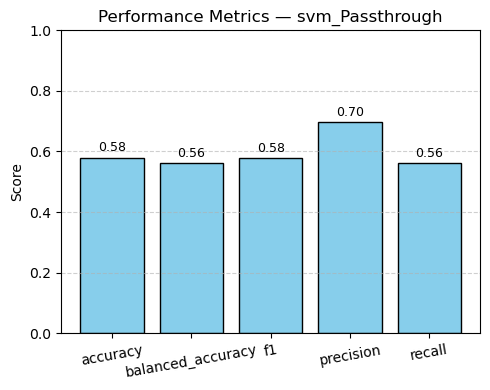

              precision    recall  f1-score   support

     Agresti       0.60      1.00      0.75         3
   Ashbacher       1.00      0.50      0.67         2
       Auken       0.50      0.50      0.50         2
 Blankenship       1.00      1.00      1.00         3
       Brody       0.50      0.33      0.40         3
       Brown       0.25      0.33      0.29         3
    Bukowsky       1.00      0.67      0.80         3
         CFH       1.00      0.33      0.50         3
   Calvinnme       1.00      1.00      1.00         3
     Chachra       0.14      1.00      0.25         4
    Chandler       0.00      0.00      0.00         3
       Chell       0.43      0.75      0.55         4
    Cholette       1.00      0.33      0.50         3
      Comdet       0.67      1.00      0.80         4
        Corn       0.29      0.67      0.40         3
       Cutey       1.00      1.00      1.00         3
    Davisson       1.00      0.25      0.40         4
        Dent       1.00    

c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

In [ ]:
# ====================== SVM with different feature selection ======================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, SelectFromModel, mutual_info_classif, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# ---------- 1) Pipeline: SelectKBest (f_classif) ----------
pipeline_skb = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(f_classif)),
    ('svm', SVC(probability=True, random_state=42))
])

param_grid_skb = {
    'scaler': [StandardScaler()],
    'selector__k': [100, 200, 300],
    'svm__C': [0.1, 1, 10],
    'svm__kernel': ['linear']  # for simplicity; can also add 'rbf'
}

print("\n=== Running GridSearch for SelectKBest (f_classif) ===")
grid_skb = GridSearchCV(pipeline_skb, param_grid_skb, cv=kfold_cv,
                        scoring='accuracy', n_jobs=-1, verbose=1, return_train_score=False)
grid_skb.fit(X_train, y_train)
print("Done SelectKBest search.")
print("Best CV score:", grid_skb.best_score_)
print("Best params:", grid_skb.best_params_)

# ---------- 2) Pipeline: SelectFromModel (RandomForest) ----------
rf_for_sel = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)
pipeline_sfm = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectFromModel(estimator=rf_for_sel, threshold='median')),
    ('svm', SVC(probability=True, random_state=42))
])

param_grid_sfm = {
    'scaler': [StandardScaler()],
    'svm__C': [0.1, 1, 10],
    'svm__kernel': ['linear']  # or add 'rbf'
}

print("\n=== Running GridSearch for SelectFromModel(RandomForest) ===")
grid_sfm = GridSearchCV(pipeline_sfm, param_grid_sfm, cv=kfold_cv,
                        scoring='accuracy', n_jobs=-1, verbose=1, return_train_score=False)
grid_sfm.fit(X_train, y_train)
print("Done SelectFromModel(RF) search.")
print("Best CV score:", grid_sfm.best_score_)
print("Best params:", grid_sfm.best_params_)

# ---------- 3) Pipeline: passthrough (no selection) ----------
pipeline_pass = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', 'passthrough'),
    ('svm', SVC(probability=True, random_state=42))
])

param_grid_pass = {
    'scaler': [StandardScaler()],
    'svm__C': [0.1, 1, 10],
    'svm__kernel': ['linear']
}

print("\n=== Running GridSearch for Passthrough (no selection) ===")
grid_pass = GridSearchCV(pipeline_pass, param_grid_pass, cv=kfold_cv,
                         scoring='accuracy', n_jobs=-1, verbose=1, return_train_score=False)
grid_pass.fit(X_train, y_train)
print("Done passthrough search.")
print("Best CV score:", grid_pass.best_score_)
print("Best params:", grid_pass.best_params_)

# ---------- Helper for readable scaler name ----------
def scaler_name(x):
    if isinstance(x, str):
        return x
    try:
        return x.__class__.__name__
    except Exception:
        return str(x)

# ---------- Function to analyze a fitted GridSearchCV object ----------
def analyze_grid(grid, title_prefix=''):
    cv = pd.DataFrame(grid.cv_results_)
    cv['scaler_name'] = cv['param_scaler'].apply(scaler_name)
    # add selector k if present
    if 'param_selector__k' in cv.columns:
        cv['selector__k'] = pd.to_numeric(cv['param_selector__k'], errors='coerce')
    top = cv.sort_values('mean_test_score', ascending=False).head(10)
    print(f"\nTop 10 CV configurations for {title_prefix}:")
    cols_show = ['mean_test_score', 'param_scaler', 'param_selector__k', 'param_svm__C', 'param_svm__kernel']
    cols_show = [c for c in cols_show if c in top.columns]
    print(top[cols_show].to_string(index=False))
    return cv

# ---------- Analyze each grid separately ----------
cv_skb = analyze_grid(grid_skb, title_prefix='SelectKBest_f_classif')
cv_sfm = analyze_grid(grid_sfm, title_prefix='SelectFromModel_RF')
cv_pass = analyze_grid(grid_pass, title_prefix='Passthrough')

# ---------- Optional: Combined comparison bar chart ----------
best_scores = pd.DataFrame({
    'selector': ['SelectKBest_f', 'SelectFromModel_RF', 'Passthrough'],
    'best_cv': [grid_skb.best_score_, grid_sfm.best_score_, grid_pass.best_score_]
}).sort_values('best_cv', ascending=False)

plt.figure(figsize=(6,4))
plt.bar(best_scores['selector'], best_scores['best_cv'])
plt.ylim(0,1)
plt.ylabel('Best CV Accuracy')
plt.title('Best CV Accuracy by feature selection (SVM)')
for i, v in enumerate(best_scores['best_cv']):
    plt.text(i, v + 0.005, f"{v:.3f}", ha='center')
plt.tight_layout()
plt.show()

# ---------- Final test-evaluations for each best pipeline ----------
for name, best_grid in [('SelectKBest_f', grid_skb), ('SelectFromModel_RF', grid_sfm), ('Passthrough', grid_pass)]:
    best_pipe = best_grid.best_estimator_
    y_pred = best_pipe.predict(X_test)
    print(f"\n=== Test set evaluation for {name} ===")
    evaluation = evaluate_run(name=f'svm_{name}', y_true=y_test, y_pred=y_pred, task_type='classification')
    plot_metrics(evaluation, figsize=(5,4), x_rotation=10)
    from sklearn.metrics import classification_report
    print(classification_report(y_test, y_pred))



--- Starting FINETUNED SVM Search (Linear + RBF) ---
Fitting 10 folds for each of 300 candidates, totalling 3000 fits


c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [2344 2916 3112 3293] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw



--- SVM Search Complete ---
Best SVM Score (CV Accuracy): 0.6250
Best SVM Parameters Found:
{'scaler': StandardScaler(), 'selector__k': 150, 'svm__C': 0.05, 'svm__kernel': 'linear'}

Best CV accuracy per scaler (overall):
      scaler_name  mean_test_score
0  StandardScaler            0.625
1     passthrough            0.445


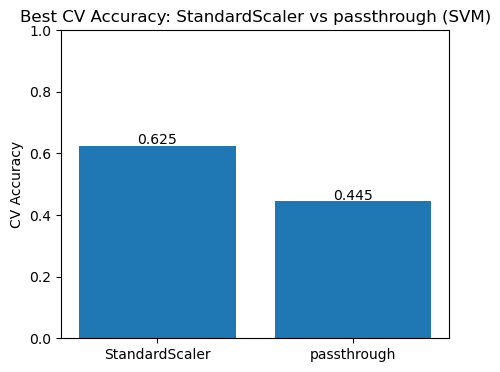

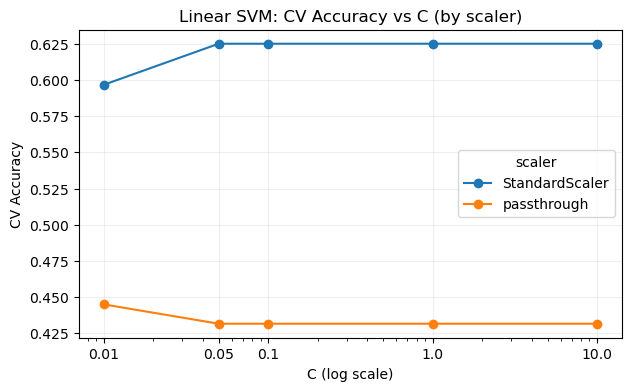


Linear kernel: best accuracy by (scaler, C):
scaler_name
StandardScaler    0.625
passthrough       0.445
dtype: float64


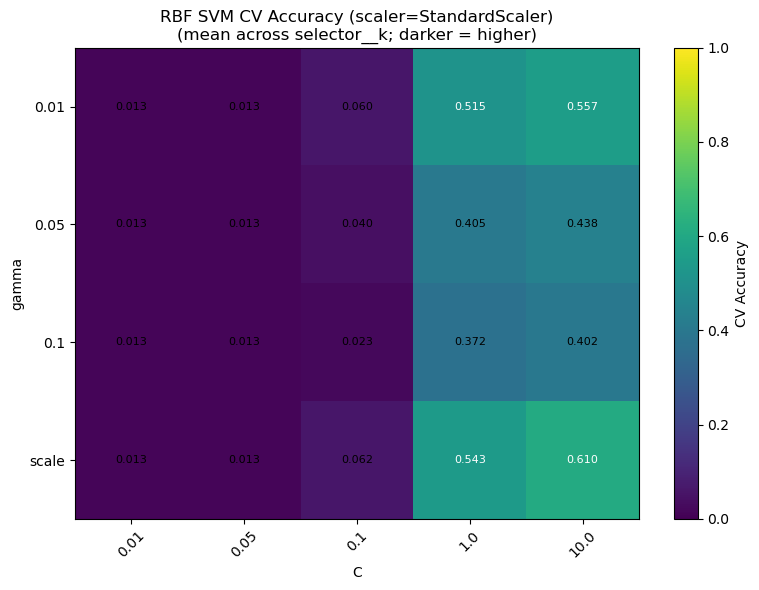

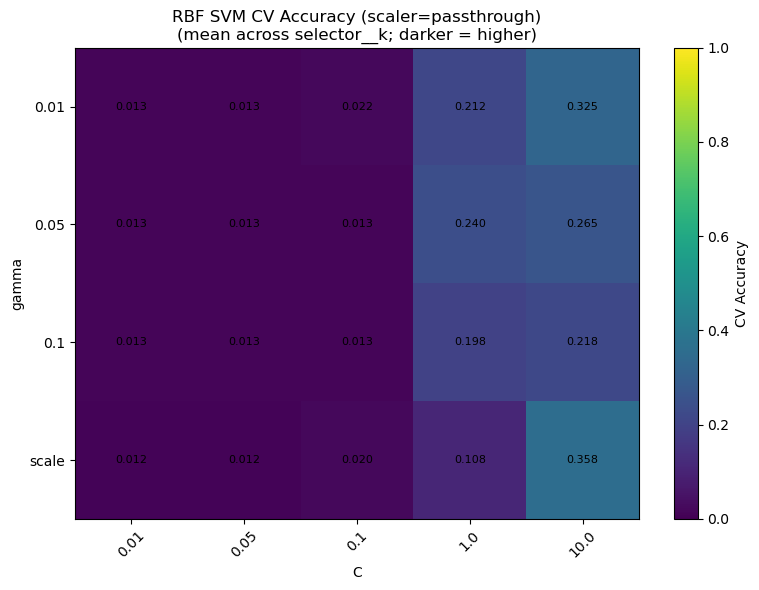


Top RBF configurations (scaler, gamma, C) by CV accuracy:
       scaler_name gamma_str     C  mean_test_score
19  StandardScaler     scale  10.0         0.610000
4   StandardScaler      0.01  10.0         0.556667
18  StandardScaler     scale   1.0         0.543333
3   StandardScaler      0.01   1.0         0.515000
9   StandardScaler      0.05  10.0         0.438333
8   StandardScaler      0.05   1.0         0.405000
14  StandardScaler       0.1  10.0         0.401667
13  StandardScaler       0.1   1.0         0.371667
39     passthrough     scale  10.0         0.358333
24     passthrough      0.01  10.0         0.325000

Best CV accuracy by kernel and scaler:
   kernel     scaler_name  mean_test_score
0  linear  StandardScaler         0.625000
2     rbf  StandardScaler         0.610000
1  linear     passthrough         0.445000
3     rbf     passthrough         0.358333


c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


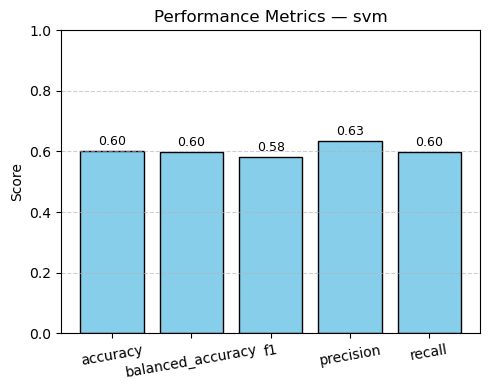


Classification report (test set) for best SVM:
              precision    recall  f1-score   support

     Agresti       0.67      0.67      0.67         3
   Ashbacher       1.00      0.50      0.67         2
       Auken       0.50      0.50      0.50         2
 Blankenship       1.00      1.00      1.00         3
       Brody       0.50      0.67      0.57         3
       Brown       0.33      0.67      0.44         3
    Bukowsky       0.33      0.33      0.33         3
         CFH       1.00      0.67      0.80         3
   Calvinnme       0.00      0.00      0.00         3
     Chachra       0.67      1.00      0.80         4
    Chandler       0.50      0.67      0.57         3
       Chell       0.20      0.25      0.22         4
    Cholette       0.50      0.67      0.57         3
      Comdet       0.50      0.50      0.50         4
        Corn       0.40      0.67      0.50         3
       Cutey       1.00      0.67      0.80         3
    Davisson       0.67      1.00

c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

In [ ]:
# Best feature + scaler diferences + hyperparameter tuning (RBF, linear)
# --- Algorithm 2: Support Vector Machine (SVM) ---
pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(f_classif)), # f_classif acc: 0.60
    ('svm', SVC(probability=True, random_state=42)) 
])


# --- param grids (add scaler choice to both) ---
param_grid_linear = {
    'scaler': [StandardScaler(), 'passthrough'],
    'selector__k': [50, 100, 150, 170, 200, 500],
    'svm__kernel': ['linear'],
    'svm__C': [0.01, 0.05, 0.1, 1, 10]
}

param_grid_rbf = {
    'scaler': [StandardScaler(), 'passthrough'],
    'selector__k': [50, 100, 150, 170, 200, 500],
    'svm__kernel': ['rbf'],
    'svm__C': [0.01, 0.05, 0.1, 1, 10],
    'svm__gamma': ['scale', 0.01, 0.05, 0.1]
}

print("\n--- Starting FINETUNED SVM Search (Linear + RBF) ---")
# We pass the list of grids to the 'param_grid' argument
grid_svm = GridSearchCV(
    pipeline_svm,
    [param_grid_linear, param_grid_rbf],
    cv=kfold_cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    return_train_score=False
)
grid_svm.fit(X_train, y_train)
print("\n--- SVM Search Complete ---")
print(f"Best SVM Score (CV Accuracy): {grid_svm.best_score_:.4f}")
print("Best SVM Parameters Found:")
print(grid_svm.best_params_)

# === extract cv results into DataFrame for plotting/analysis ===
cv = pd.DataFrame(grid_svm.cv_results_)

# helper: normalize scaler name
def scaler_name(x):
    if isinstance(x, str):
        return x
    try:
        return x.__class__.__name__
    except Exception:
        return str(x)

cv['scaler_name'] = cv['param_scaler'].apply(scaler_name)
cv['C'] = cv['param_svm__C'].astype(float)
# gamma can be 'scale' or numeric -> convert to string for pivoting/labels
cv['gamma_str'] = cv['param_svm__gamma'].astype(str)
cv['kernel'] = cv['param_svm__kernel'].astype(str)
cv['selector_k'] = cv['param_selector__k'].astype(int)
cv['mean_test_score'] = cv['mean_test_score'].astype(float)

# --- 1) Best CV accuracy per scaler (overall, across kernels and other params) ---
best_per_scaler = cv.groupby('scaler_name')['mean_test_score'].max().reset_index().sort_values('mean_test_score', ascending=False)
print("\nBest CV accuracy per scaler (overall):")
print(best_per_scaler)

# bar plot: best per scaler
plt.figure(figsize=(5,4))
plt.bar(best_per_scaler['scaler_name'], best_per_scaler['mean_test_score'])
plt.ylim(0,1)
plt.ylabel('CV Accuracy')
plt.title('Best CV Accuracy: StandardScaler vs passthrough (SVM)')
for i, v in enumerate(best_per_scaler['mean_test_score']):
    plt.text(i, v + 0.005, f"{v:.3f}", ha='center')
plt.show()

# --- 2) Linear kernel: accuracy vs C (one line per scaler) ---
linear = cv[cv['kernel'] == 'linear'].copy()
if linear.shape[0] == 0:
    print("No linear-kernel runs found in cv results.")
else:
    # choose best mean_test_score across selector__k for each (scaler, C)
    agg_linear = linear.groupby(['scaler_name', 'C'])['mean_test_score'].max().unstack('scaler_name').sort_index()
    plt.figure(figsize=(7,4))
    for col in agg_linear.columns:
        plt.semilogx(agg_linear.index, agg_linear[col], marker='o', label=col)  # semilog for C
    plt.xlabel('C (log scale)')
    plt.ylabel('CV Accuracy')
    plt.title('Linear SVM: CV Accuracy vs C (by scaler)')
    plt.xticks(agg_linear.index, agg_linear.index)
    plt.grid(alpha=0.2)
    plt.legend(title='scaler')
    plt.show()
    print("\nLinear kernel: best accuracy by (scaler, C):")
    print(agg_linear.max().sort_values(ascending=False))

# --- 3) RBF kernel: heatmap(s) of accuracy by (gamma × C) for each scaler ---
rbf = cv[cv['kernel'] == 'rbf'].copy()
if rbf.shape[0] == 0:
    print("No RBF-kernel runs found in cv results.")
else:
    scalers = rbf['scaler_name'].unique()
    # create one heatmap per scaler
    for sc in scalers:
        df = rbf[rbf['scaler_name'] == sc]
        # pivot table: rows = gamma_str, cols = C
        pivot = df.groupby(['gamma_str', 'C'])['mean_test_score'].max().unstack(level=1)
        # sort columns by numeric C order
        pivot = pivot.reindex(columns=sorted(pivot.columns))
        # convert pivot to numpy matrix for imshow
        mat = pivot.values
        plt.figure(figsize=(8, 4 + 0.5 * len(pivot)))
        im = plt.imshow(mat, aspect='auto', vmin=0, vmax=1)
        plt.colorbar(im, label='CV Accuracy')
        plt.yticks(np.arange(len(pivot.index)), pivot.index)
        plt.xticks(np.arange(len(pivot.columns)), [str(c) for c in pivot.columns], rotation=45)
        plt.xlabel('C')
        plt.ylabel('gamma')
        plt.title(f'RBF SVM CV Accuracy (scaler={sc})\n(mean across selector__k; darker = higher)')
        # annotate numbers
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                val = mat[i, j]
                if not np.isnan(val):
                    plt.text(j, i, f"{val:.3f}", ha='center', va='center', fontsize=8, color='white' if val > 0.5 else 'black')
        plt.tight_layout()
        plt.show()

    # summary: best per (scaler, gamma, C)
    best_rbf = rbf.groupby(['scaler_name', 'gamma_str', 'C'])['mean_test_score'].max().reset_index()
    best_rbf_sorted = best_rbf.sort_values('mean_test_score', ascending=False).head(10)
    print("\nTop RBF configurations (scaler, gamma, C) by CV accuracy:")
    print(best_rbf_sorted)

# --- 4) summary by kernel + scaler ---
best_by_kernel_scaler = cv.groupby(['kernel', 'scaler_name'])['mean_test_score'].max().reset_index().sort_values('mean_test_score', ascending=False)
print("\nBest CV accuracy by kernel and scaler:")
print(best_by_kernel_scaler)

# === final test-evaluation using the overall best estimator ===
best_svm = grid_svm.best_estimator_
y_pred_svm = best_svm.predict(X_test)

evaluation = evaluate_run(name='svm', y_true=y_test, y_pred=y_pred_svm, task_type='classification')
plot_metrics(evaluation, figsize=(5,4), x_rotation=10)

print("\nClassification report (test set) for best SVM:")
print(classification_report(y_test, y_pred_svm))


--- Starting FINETUNED SVM Search (Linear + RBF) ---
Fitting 10 folds for each of 300 candidates, totalling 3000 fits


c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [2344 2916 3112 3293] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw



--- SVM Search Complete ---
Best CV Accuracy: 0.6250
Best Parameters: {'scaler': StandardScaler(), 'selector__k': 150, 'svm__C': 0.05, 'svm__kernel': 'linear'}


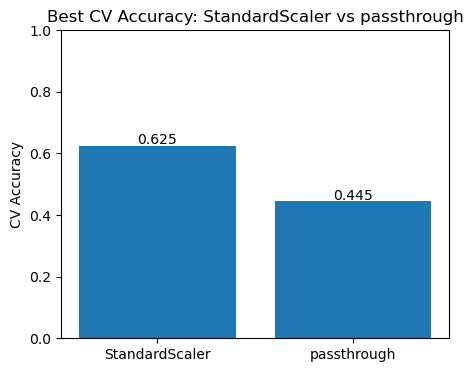

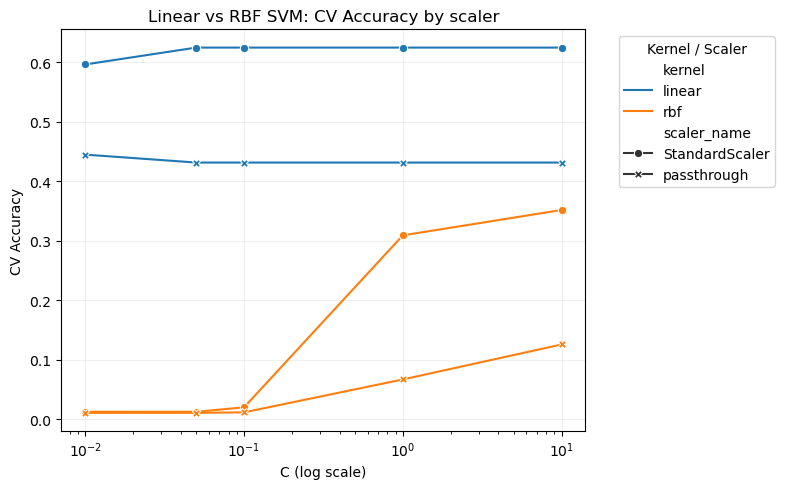

c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


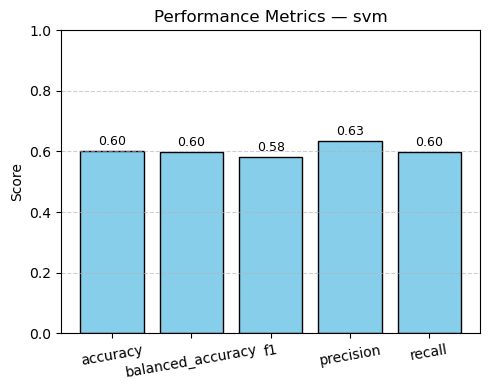


Classification report (test set) for best SVM:
              precision    recall  f1-score   support

     Agresti       0.67      0.67      0.67         3
   Ashbacher       1.00      0.50      0.67         2
       Auken       0.50      0.50      0.50         2
 Blankenship       1.00      1.00      1.00         3
       Brody       0.50      0.67      0.57         3
       Brown       0.33      0.67      0.44         3
    Bukowsky       0.33      0.33      0.33         3
         CFH       1.00      0.67      0.80         3
   Calvinnme       0.00      0.00      0.00         3
     Chachra       0.67      1.00      0.80         4
    Chandler       0.50      0.67      0.57         3
       Chell       0.20      0.25      0.22         4
    Cholette       0.50      0.67      0.57         3
      Comdet       0.50      0.50      0.50         4
        Corn       0.40      0.67      0.50         3
       Cutey       1.00      0.67      0.80         3
    Davisson       0.67      1.00

c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

# -----------------------------
# Pipeline setup
# -----------------------------
pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(f_classif)),  # feature selection
    ('svm', SVC(probability=True, random_state=42))
])

# -----------------------------
# Param grids for Linear and RBF
# -----------------------------
param_grid_linear = {
    'scaler': [StandardScaler(), 'passthrough'],
    'selector__k': [50, 100, 150, 170, 200, 500],
    'svm__kernel': ['linear'],
    'svm__C': [0.01, 0.05, 0.1, 1, 10]
}

param_grid_rbf = {
    'scaler': [StandardScaler(), 'passthrough'],
    'selector__k': [50, 100, 150, 170, 200, 500],
    'svm__kernel': ['rbf'],
    'svm__C': [0.01, 0.05, 0.1, 1, 10],
    'svm__gamma': ['scale', 0.01, 0.05, 0.1]
}

# -----------------------------
# Run GridSearchCV
# -----------------------------
print("\n--- Starting FINETUNED SVM Search (Linear + RBF) ---")
grid_svm = GridSearchCV(
    pipeline_svm,
    [param_grid_linear, param_grid_rbf],
    cv=kfold_cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    return_train_score=False
)
grid_svm.fit(X_train, y_train)
print("\n--- SVM Search Complete ---")
print(f"Best CV Accuracy: {grid_svm.best_score_:.4f}")
print("Best Parameters:", grid_svm.best_params_)

# -----------------------------
# Extract CV results
# -----------------------------
cv = pd.DataFrame(grid_svm.cv_results_)

# Helper: readable scaler name
def scaler_name(x):
    if isinstance(x, str):
        return x
    try:
        return x.__class__.__name__
    except:
        return str(x)

cv['scaler_name'] = cv['param_scaler'].apply(scaler_name)
cv['C'] = cv['param_svm__C'].astype(float)
cv['gamma_str'] = cv['param_svm__gamma'].astype(str)
cv['kernel'] = cv['param_svm__kernel'].astype(str)
cv['selector_k'] = cv['param_selector__k'].astype(int)
cv['mean_test_score'] = cv['mean_test_score'].astype(float)

# -----------------------------
# 1) Best CV accuracy per scaler
# -----------------------------
best_per_scaler = cv.groupby('scaler_name')['mean_test_score'].max().reset_index().sort_values('mean_test_score', ascending=False)
plt.figure(figsize=(5,4))
plt.bar(best_per_scaler['scaler_name'], best_per_scaler['mean_test_score'])
plt.ylim(0,1)
plt.ylabel('CV Accuracy')
plt.title('Best CV Accuracy: StandardScaler vs passthrough')
for i, v in enumerate(best_per_scaler['mean_test_score']):
    plt.text(i, v + 0.005, f"{v:.3f}", ha='center')
plt.show()

# -----------------------------
# 2) Compare Linear vs RBF
# -----------------------------
# Linear: best across selector__k
linear_summary = cv[cv['kernel']=='linear'].groupby(['scaler_name','C'])['mean_test_score'].max().reset_index()
linear_summary['gamma_str'] = 'linear'
linear_summary['kernel'] = 'linear'

# RBF: best across selector__k, average across gamma
rbf_summary = cv[cv['kernel']=='rbf']
rbf_avg = rbf_summary.groupby(['scaler_name','C'])['mean_test_score'].mean().reset_index()
rbf_avg['kernel'] = 'rbf'

# Combine
compare_df = pd.concat([
    linear_summary.rename(columns={'mean_test_score':'CV Accuracy'}),
    rbf_avg.rename(columns={'mean_test_score':'CV Accuracy'})
], axis=0)

plt.figure(figsize=(8,5))
sns.lineplot(data=compare_df, x='C', y='CV Accuracy', hue='kernel', style='scaler_name', markers=True, dashes=False)
plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('CV Accuracy')
plt.title('Linear vs RBF SVM: CV Accuracy by scaler')
plt.grid(alpha=0.2)
plt.legend(title='Kernel / Scaler', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

# -----------------------------

# -----------------------------
# 4) Test evaluation using best estimator
# -----------------------------
best_svm = grid_svm.best_estimator_
y_pred_svm = best_svm.predict(X_test)

evaluation = evaluate_run(name='svm', y_true=y_test, y_pred=y_pred_svm, task_type='classification')
plot_metrics(evaluation, figsize=(5,4), x_rotation=10)

print("\nClassification report (test set) for best SVM:")
print(classification_report(y_test, y_pred_svm))

# -----------------------------
# 5) Summary of best CV accuracy by kernel and scaler
# -----------------------------
best_by_kernel_scaler = cv.groupby(['kernel','scaler_name'])['mean_test_score'].max().reset_index().sort_values('mean_test_score', ascending=False)
print("\nBest CV accuracy by kernel and scaler:")
print(best_by_kernel_scaler)


wanted to do Recursive Feature Elimination, but realized that would take forever in case of 10k features -> check if there is threshold setting for this

# Decision Tree

not good for many features low sample size -> overfit on high dimensional data


=== Running GridSearch for SelectKBest ===
Fitting 10 folds for each of 480 candidates, totalling 4800 fits


c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [2344 2916 3112 3293] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Done SelectKBest search.
Best CV score: 0.3983333333333333
Best params: {'dt__criterion': 'gini', 'dt__max_depth': None, 'dt__min_samples_leaf': 5, 'scaler': StandardScaler(), 'selector__k': 150}

=== Running GridSearch for SelectFromModel(RF) ===
Fitting 10 folds for each of 80 candidates, totalling 800 fits
Done SelectFromModel search.
Best CV score: 0.32499999999999996
Best params: {'dt__criterion': 'gini', 'dt__max_depth': None, 'dt__min_samples_leaf': 3, 'scaler': 'passthrough'}

=== Running GridSearch for Passthrough ===
Fitting 10 folds for each of 80 candidates, totalling 800 fits
Done Passthrough search.
Best CV score: 0.33333333333333337
Best params: {'dt__criterion': 'gini', 'dt__max_depth': None, 'dt__min_samples_leaf': 3, 'scaler': 'passthrough'}


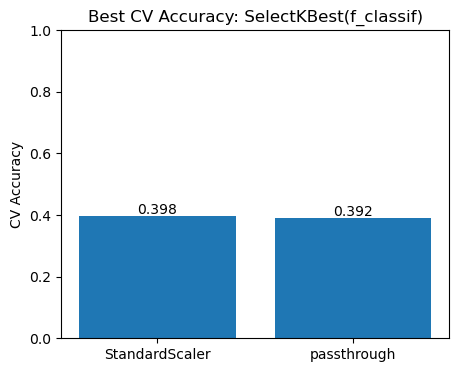

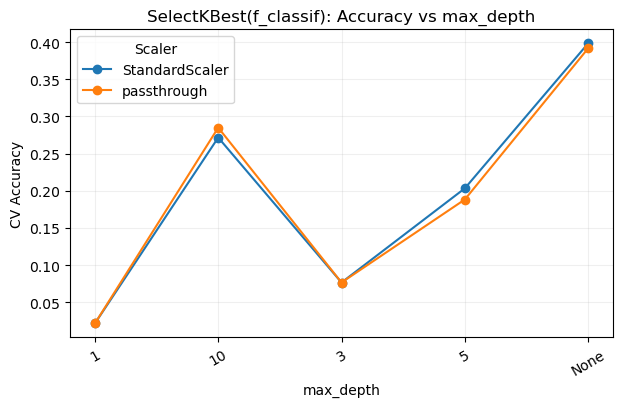

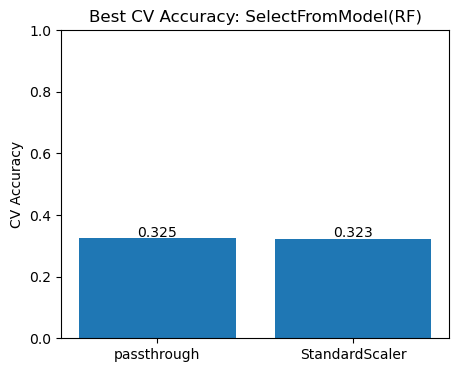

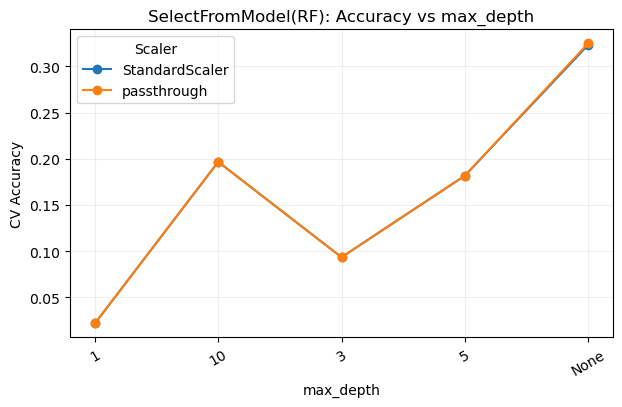

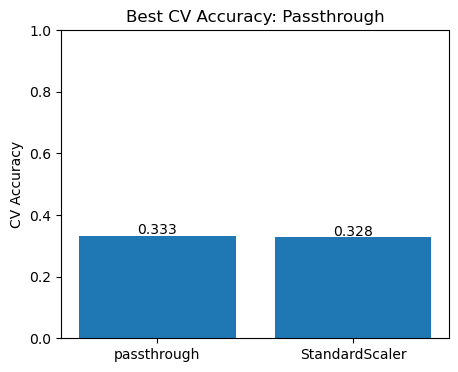

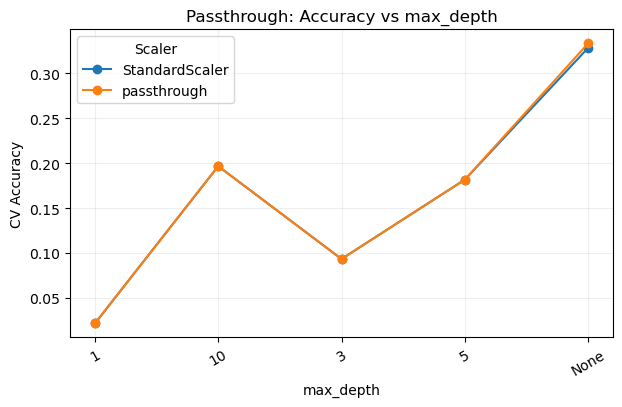


=== Test set evaluation for SelectKBest ===
Accuracy: 0.3467


c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


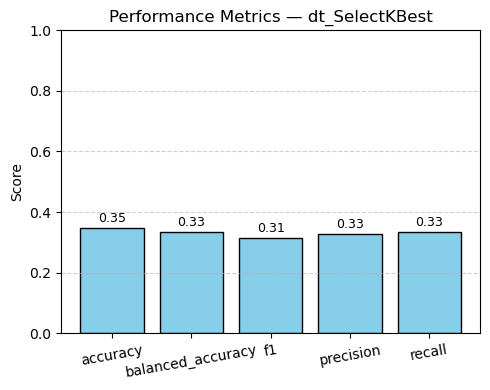

              precision    recall  f1-score   support

     Agresti       0.00      0.00      0.00         3
   Ashbacher       0.00      0.00      0.00         2
       Auken       0.00      0.00      0.00         2
 Blankenship       1.00      1.00      1.00         3
       Brody       0.00      0.00      0.00         3
       Brown       0.00      0.00      0.00         3
    Bukowsky       0.00      0.00      0.00         3
         CFH       0.14      0.33      0.20         3
   Calvinnme       0.00      0.00      0.00         3
     Chachra       0.60      0.75      0.67         4
    Chandler       1.00      0.33      0.50         3
       Chell       0.50      0.75      0.60         4
    Cholette       0.00      0.00      0.00         3
      Comdet       0.00      0.00      0.00         4
        Corn       0.00      0.00      0.00         3
       Cutey       0.00      0.00      0.00         3
    Davisson       0.20      0.25      0.22         4
        Dent       0.50    

c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c


=== Test set evaluation for SelectFromModel_RF ===
Accuracy: 0.3467


c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


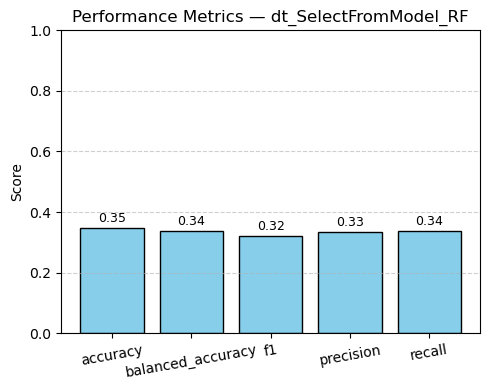

c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

              precision    recall  f1-score   support

     Agresti       0.00      0.00      0.00         3
   Ashbacher       1.00      0.50      0.67         2
       Auken       0.00      0.00      0.00         2
 Blankenship       1.00      1.00      1.00         3
       Brody       0.50      0.33      0.40         3
       Brown       0.00      0.00      0.00         3
    Bukowsky       0.22      0.67      0.33         3
         CFH       0.17      0.33      0.22         3
   Calvinnme       0.20      0.33      0.25         3
     Chachra       0.25      0.50      0.33         4
    Chandler       0.20      0.33      0.25         3
       Chell       0.17      0.25      0.20         4
    Cholette       0.00      0.00      0.00         3
      Comdet       0.25      0.50      0.33         4
        Corn       0.00      0.00      0.00         3
       Cutey       0.00      0.00      0.00         3
    Davisson       0.00      0.00      0.00         4
        Dent       0.25    

c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


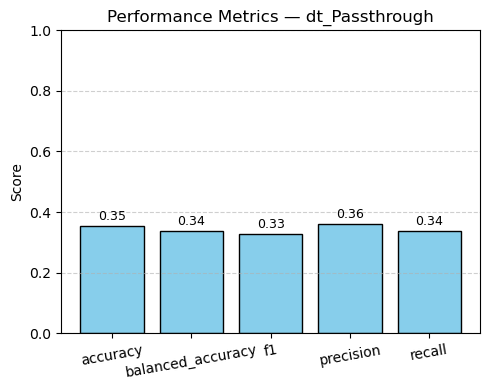

              precision    recall  f1-score   support

     Agresti       0.00      0.00      0.00         3
   Ashbacher       0.00      0.00      0.00         2
       Auken       0.00      0.00      0.00         2
 Blankenship       0.75      1.00      0.86         3
       Brody       0.50      0.33      0.40         3
       Brown       0.00      0.00      0.00         3
    Bukowsky       0.25      0.67      0.36         3
         CFH       0.50      0.33      0.40         3
   Calvinnme       0.00      0.00      0.00         3
     Chachra       0.25      0.50      0.33         4
    Chandler       0.33      0.33      0.33         3
       Chell       1.00      0.50      0.67         4
    Cholette       0.00      0.00      0.00         3
      Comdet       0.20      0.50      0.29         4
        Corn       0.00      0.00      0.00         3
       Cutey       0.00      0.00      0.00         3
    Davisson       0.33      0.25      0.29         4
        Dent       1.00    

c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif, SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score

# -----------------------------
# 1) Pipeline: SelectKBest(f_classif)
# -----------------------------
pipeline_skb = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(f_classif)),
    ('dt', DecisionTreeClassifier(random_state=42))
])

param_grid_skb = {
    'scaler': [StandardScaler(), 'passthrough'],
    'selector__k': [50, 75, 100, 125, 150, 200],
    'dt__max_depth': [1, 3, 5, 10, None],
    'dt__criterion': ['gini', 'entropy'],
    'dt__min_samples_leaf': [3, 5, 10, 20]
}

print("\n=== Running GridSearch for SelectKBest ===")
grid_skb = GridSearchCV(pipeline_skb, param_grid_skb, cv=kfold_cv,
                        scoring='accuracy', n_jobs=-1, verbose=1, return_train_score=False)
grid_skb.fit(X_train, y_train)
print("Done SelectKBest search.")
print("Best CV score:", grid_skb.best_score_)
print("Best params:", grid_skb.best_params_)

# -----------------------------
# 2) Pipeline: SelectFromModel(RandomForest)
# -----------------------------
rf_for_sel = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)
pipeline_sfm = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectFromModel(rf_for_sel, threshold='median')),
    ('dt', DecisionTreeClassifier(random_state=42))
])

param_grid_sfm = {
    'scaler': [StandardScaler(), 'passthrough'],
    'dt__max_depth': [1, 3, 5, 10, None],
    'dt__criterion': ['gini', 'entropy'],
    'dt__min_samples_leaf': [3, 5, 10, 20]
}

print("\n=== Running GridSearch for SelectFromModel(RF) ===")
grid_sfm = GridSearchCV(pipeline_sfm, param_grid_sfm, cv=kfold_cv,
                        scoring='accuracy', n_jobs=-1, verbose=1, return_train_score=False)
grid_sfm.fit(X_train, y_train)
print("Done SelectFromModel search.")
print("Best CV score:", grid_sfm.best_score_)
print("Best params:", grid_sfm.best_params_)

# -----------------------------
# 3) Pipeline: passthrough (no feature selection)
# -----------------------------
pipeline_pass = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', 'passthrough'),
    ('dt', DecisionTreeClassifier(random_state=42))
])

param_grid_pass = {
    'scaler': [StandardScaler(), 'passthrough'],
    'dt__max_depth': [1, 3, 5, 10, None],
    'dt__criterion': ['gini', 'entropy'],
    'dt__min_samples_leaf': [3, 5, 10, 20]
}

print("\n=== Running GridSearch for Passthrough ===")
grid_pass = GridSearchCV(pipeline_pass, param_grid_pass, cv=kfold_cv,
                         scoring='accuracy', n_jobs=-1, verbose=1, return_train_score=False)
grid_pass.fit(X_train, y_train)
print("Done Passthrough search.")
print("Best CV score:", grid_pass.best_score_)
print("Best params:", grid_pass.best_params_)

# -----------------------------
# Helper: readable scaler
# -----------------------------
def scaler_name(x):
    if isinstance(x, str):
        return x
    try:
        return x.__class__.__name__
    except:
        return str(x)

# -----------------------------
# Analyze and plot: best CV accuracy per scaler
# -----------------------------
def analyze_dt_grid(grid, title):
    cv = pd.DataFrame(grid.cv_results_)
    cv['scaler_name'] = cv['param_scaler'].apply(scaler_name)
    cv['max_depth_str'] = cv['param_dt__max_depth'].apply(lambda x: 'None' if pd.isna(x) else str(x))
    cv['max_depth_sort'] = cv['param_dt__max_depth'].apply(lambda x: np.inf if pd.isna(x) else float(x))
    cv['mean_test_score'] = cv['mean_test_score'].astype(float)

    # 1) Best per scaler
    best_per_scaler = cv.groupby('scaler_name')['mean_test_score'].max().reset_index().sort_values('mean_test_score', ascending=False)
    plt.figure(figsize=(5,4))
    plt.bar(best_per_scaler['scaler_name'], best_per_scaler['mean_test_score'])
    plt.ylim(0,1)
    plt.ylabel('CV Accuracy')
    plt.title(f'Best CV Accuracy: {title}')
    for i, v in enumerate(best_per_scaler['mean_test_score']):
        plt.text(i, v + 0.005, f"{v:.3f}", ha='center')
    plt.show()

    # 2) Accuracy vs max_depth
    agg = cv.groupby(['scaler_name', 'max_depth_str', 'max_depth_sort'])['mean_test_score'].max().reset_index()
    agg = agg.sort_values(['scaler_name','max_depth_sort'])
    pivot = agg.pivot(index='max_depth_str', columns='scaler_name', values='mean_test_score')
    
    plt.figure(figsize=(7,4))
    for col in pivot.columns:
        plt.plot(pivot.index, pivot[col], marker='o', label=col)
    plt.xlabel('max_depth')
    plt.ylabel('CV Accuracy')
    plt.title(f'{title}: Accuracy vs max_depth')
    plt.legend(title='Scaler')
    plt.grid(alpha=0.2)
    plt.xticks(rotation=30)
    plt.show()
    
    # return cv for further analysis if needed
    return cv

cv_skb = analyze_dt_grid(grid_skb, 'SelectKBest(f_classif)')
cv_sfm = analyze_dt_grid(grid_sfm, 'SelectFromModel(RF)')
cv_pass = analyze_dt_grid(grid_pass, 'Passthrough')

# -----------------------------
# Final test evaluation
# -----------------------------
for name, grid in zip(['SelectKBest', 'SelectFromModel_RF', 'Passthrough'],
                      [grid_skb, grid_sfm, grid_pass]):
    best_dt = grid.best_estimator_
    y_pred = best_dt.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n=== Test set evaluation for {name} ===")
    print(f"Accuracy: {acc:.4f}")
    evaluation = evaluate_run(name=f'dt_{name}', y_true=y_test, y_pred=y_pred, task_type='classification')
    plot_metrics(evaluation, figsize=(5,4), x_rotation=10)
    # print(classification_report(y_test, y_pred))



=== Running GridSearch for SelectKBest ===
Fitting 10 folds for each of 480 candidates, totalling 4800 fits


c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [2344 2916 3112 3293] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Done SelectKBest search.
Best CV score: 0.3983333333333333
Best params: {'dt__criterion': 'gini', 'dt__max_depth': None, 'dt__min_samples_leaf': 5, 'scaler': StandardScaler(), 'selector__k': 150}

=== Running GridSearch for SelectFromModel(RF) ===
Fitting 10 folds for each of 80 candidates, totalling 800 fits
Done SelectFromModel search.
Best CV score: 0.32499999999999996
Best params: {'dt__criterion': 'gini', 'dt__max_depth': None, 'dt__min_samples_leaf': 3, 'scaler': 'passthrough'}

=== Running GridSearch for Passthrough ===
Fitting 10 folds for each of 80 candidates, totalling 800 fits
Done Passthrough search.
Best CV score: 0.33333333333333337
Best params: {'dt__criterion': 'gini', 'dt__max_depth': None, 'dt__min_samples_leaf': 3, 'scaler': 'passthrough'}


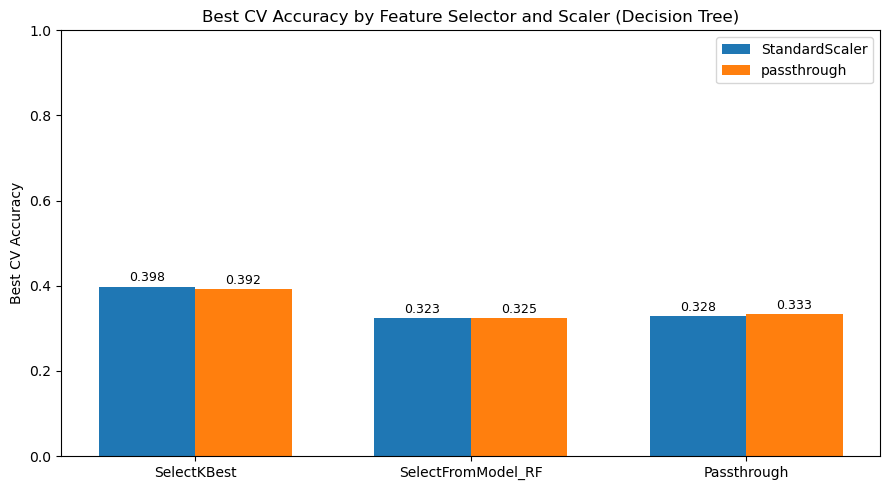

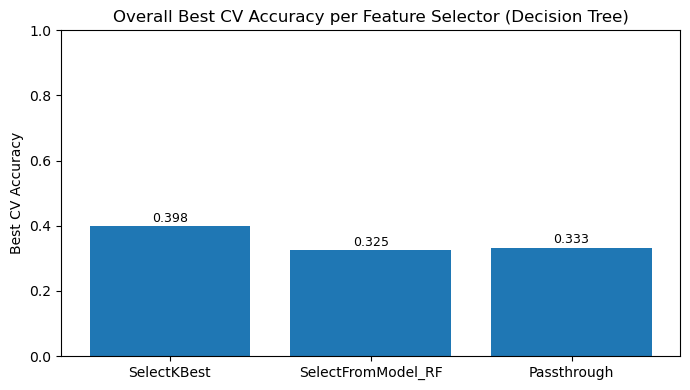


=== Test set evaluation for SelectKBest ===
Accuracy: 0.3467


c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


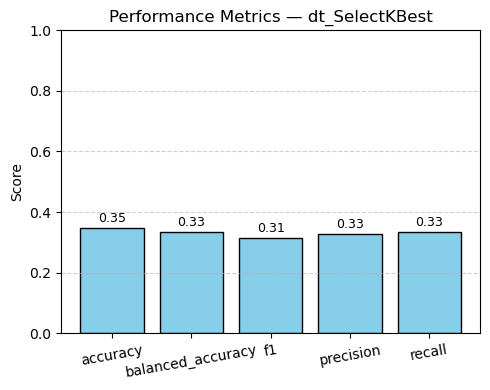


=== Test set evaluation for SelectFromModel_RF ===
Accuracy: 0.3467


c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


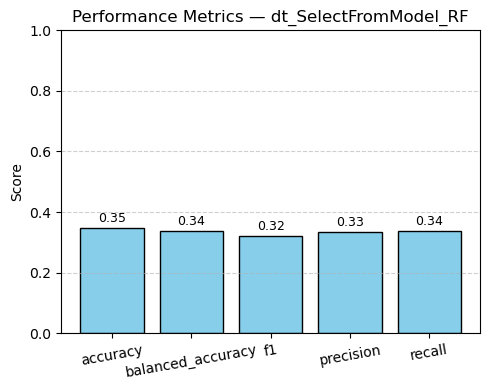


=== Test set evaluation for Passthrough ===
Accuracy: 0.3533


c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


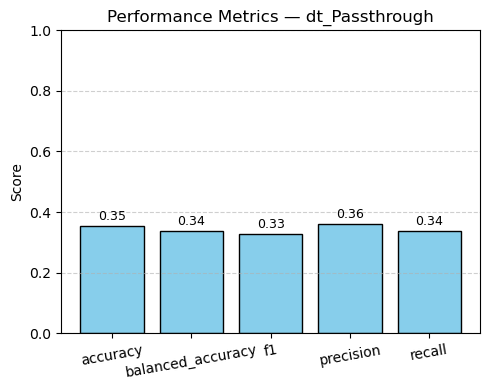

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif, SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score


# -----------------------------
# Helper: readable scaler name
# -----------------------------
def scaler_name(x):
    if isinstance(x, str):
        return x
    try:
        return x.__class__.__name__
    except:
        return str(x)

# -----------------------------
# 1) Pipeline: SelectKBest(f_classif)
# -----------------------------
pipeline_skb = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(f_classif)),
    ('dt', DecisionTreeClassifier(random_state=42))
])

param_grid_skb = {
    'scaler': [StandardScaler(), 'passthrough'],
    'selector__k': [50, 75, 100, 125, 150, 200],
    'dt__max_depth': [1, 3, 5, 10, None],
    'dt__criterion': ['gini', 'entropy'],
    'dt__min_samples_leaf': [3, 5, 10, 20]
}

print("\n=== Running GridSearch for SelectKBest ===")
grid_skb = GridSearchCV(pipeline_skb, param_grid_skb, cv=kfold_cv,
                        scoring='accuracy', n_jobs=-1, verbose=1, return_train_score=False)
grid_skb.fit(X_train, y_train)
print("Done SelectKBest search.")
print("Best CV score:", grid_skb.best_score_)
print("Best params:", grid_skb.best_params_)

# -----------------------------
# 2) Pipeline: SelectFromModel(RandomForest)
# -----------------------------
rf_for_sel = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)
pipeline_sfm = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectFromModel(rf_for_sel, threshold='median')),
    ('dt', DecisionTreeClassifier(random_state=42))
])

param_grid_sfm = {
    'scaler': [StandardScaler(), 'passthrough'],
    'dt__max_depth': [1, 3, 5, 10, None],
    'dt__criterion': ['gini', 'entropy'],
    'dt__min_samples_leaf': [3, 5, 10, 20]
}

print("\n=== Running GridSearch for SelectFromModel(RF) ===")
grid_sfm = GridSearchCV(pipeline_sfm, param_grid_sfm, cv=kfold_cv,
                        scoring='accuracy', n_jobs=-1, verbose=1, return_train_score=False)
grid_sfm.fit(X_train, y_train)
print("Done SelectFromModel search.")
print("Best CV score:", grid_sfm.best_score_)
print("Best params:", grid_sfm.best_params_)

# -----------------------------
# 3) Pipeline: passthrough (no feature selection)
# -----------------------------
pipeline_pass = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', 'passthrough'),
    ('dt', DecisionTreeClassifier(random_state=42))
])

param_grid_pass = {
    'scaler': [StandardScaler(), 'passthrough'],
    'dt__max_depth': [1, 3, 5, 10, None],
    'dt__criterion': ['gini', 'entropy'],
    'dt__min_samples_leaf': [3, 5, 10, 20]
}

print("\n=== Running GridSearch for Passthrough ===")
grid_pass = GridSearchCV(pipeline_pass, param_grid_pass, cv=kfold_cv,
                         scoring='accuracy', n_jobs=-1, verbose=1, return_train_score=False)
grid_pass.fit(X_train, y_train)
print("Done Passthrough search.")
print("Best CV score:", grid_pass.best_score_)
print("Best params:", grid_pass.best_params_)

# -----------------------------
# Helper function to extract best CV per scaler
# -----------------------------
def get_best_per_scaler(grid):
    cv = pd.DataFrame(grid.cv_results_)
    cv['scaler_name'] = cv['param_scaler'].apply(scaler_name)
    best = cv.groupby('scaler_name')['mean_test_score'].max().reset_index()
    return best.set_index('scaler_name')

best_skb_idx = get_best_per_scaler(grid_skb)
best_sfm_idx = get_best_per_scaler(grid_sfm)
best_pass_idx = get_best_per_scaler(grid_pass)

# Extract values (fill 0 if missing)
def get_val(idx_df, name):
    try:
        return float(idx_df.loc[name, 'mean_test_score'])
    except Exception:
        return 0.0

selectors = ['SelectKBest', 'SelectFromModel_RF', 'Passthrough']
std_vals = [get_val(best_skb_idx, 'StandardScaler'),
            get_val(best_sfm_idx, 'StandardScaler'),
            get_val(best_pass_idx, 'StandardScaler')]

passth_vals = [get_val(best_skb_idx, 'passthrough'),
               get_val(best_sfm_idx, 'passthrough'),
               get_val(best_pass_idx, 'passthrough')]

# --- Combined grouped bar plot: selector × scaler ---
x = np.arange(len(selectors))
width = 0.35
plt.figure(figsize=(9,5))
bars1 = plt.bar(x - width/2, std_vals, width, label='StandardScaler')
bars2 = plt.bar(x + width/2, passth_vals, width, label='passthrough')

plt.ylim(0,1)
plt.ylabel('Best CV Accuracy')
plt.title('Best CV Accuracy by Feature Selector and Scaler (Decision Tree)')
plt.xticks(x, selectors)
plt.legend()

for b in bars1 + bars2:
    h = b.get_height()
    plt.text(b.get_x() + b.get_width()/2, h + 0.005, f"{h:.3f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# --- Simple overall best CV per selector ---
overall_vals = [grid_skb.best_score_, grid_sfm.best_score_, grid_pass.best_score_]
plt.figure(figsize=(7,4))
bars = plt.bar(selectors, overall_vals)
plt.ylim(0,1)
plt.ylabel('Best CV Accuracy')
plt.title('Overall Best CV Accuracy per Feature Selector (Decision Tree)')

for b in bars:
    h = b.get_height()
    plt.text(b.get_x() + b.get_width()/2, h + 0.005, f"{h:.3f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# -----------------------------
# Test evaluation for each selector
# -----------------------------
for name, grid in zip(['SelectKBest', 'SelectFromModel_RF', 'Passthrough'],
                      [grid_skb, grid_sfm, grid_pass]):
    best_dt = grid.best_estimator_
    y_pred = best_dt.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n=== Test set evaluation for {name} ===")
    print(f"Accuracy: {acc:.4f}")
    evaluation = evaluate_run(name=f'dt_{name}', y_true=y_test, y_pred=y_pred, task_type='classification')
    plot_metrics(evaluation, figsize=(5,4), x_rotation=10)
    # print(classification_report(y_test, y_pred))


Fitting 10 folds for each of 480 candidates, totalling 4800 fits

--- Best Decision Tree Model (overall) ---
Best Score (CV Accuracy): 0.3983
Best Parameters:
{'dt__criterion': 'gini', 'dt__max_depth': None, 'dt__min_samples_leaf': 5, 'scaler': StandardScaler(), 'selector__k': 150}

Best CV accuracy per scaler (overall):
      scaler_name  mean_test_score
0  StandardScaler         0.398333
1     passthrough         0.391667


c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [2344 2916 3112 3293] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


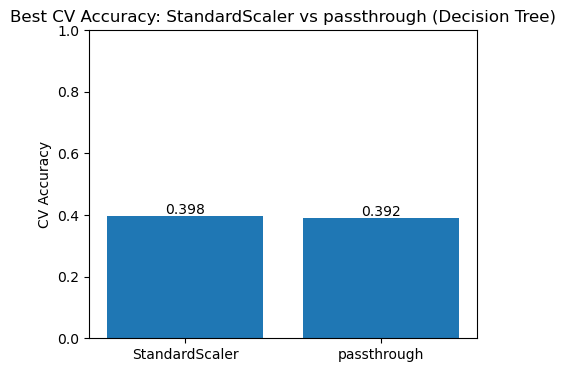

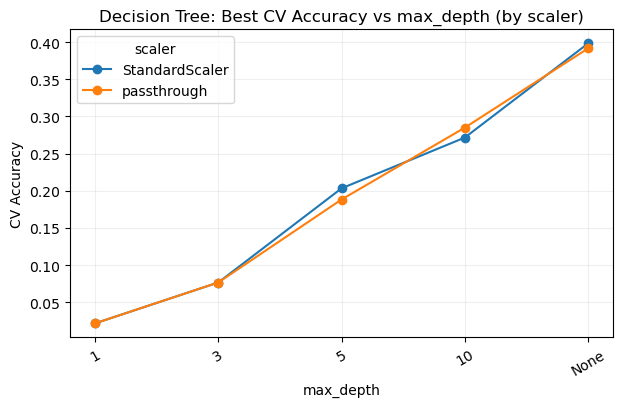


Best accuracy by (scaler, max_depth):
      scaler_name max_depth_str  max_depth_sort  mean_test_score
4  StandardScaler          None             inf         0.398333
9     passthrough          None             inf         0.391667
6     passthrough            10            10.0         0.285000
1  StandardScaler            10            10.0         0.271667
3  StandardScaler             5             5.0         0.203333
8     passthrough             5             5.0         0.188333
2  StandardScaler             3             3.0         0.076667
7     passthrough             3             3.0         0.076667
0  StandardScaler             1             1.0         0.021667
5     passthrough             1             1.0         0.021667


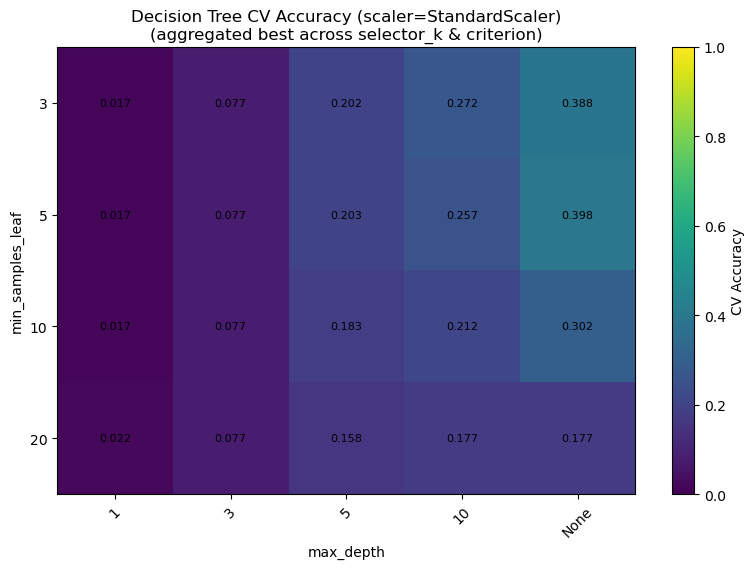

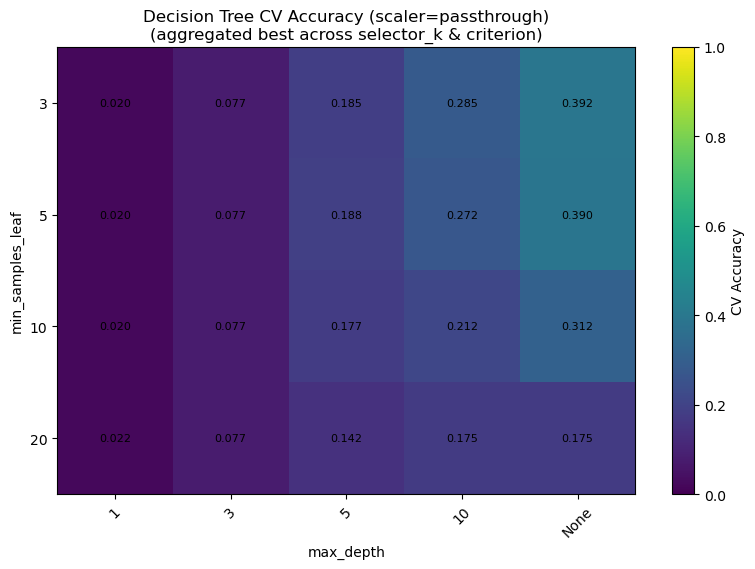


Best CV accuracy by (criterion, scaler):
  criterion     scaler_name  mean_test_score
2      gini  StandardScaler         0.398333
3      gini     passthrough         0.391667
1   entropy     passthrough         0.285000
0   entropy  StandardScaler         0.271667

DT Test Accuracy:  0.3467


c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


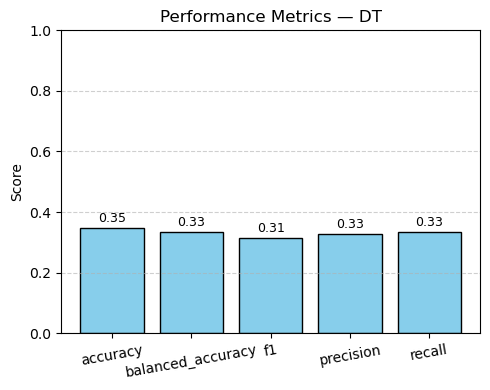


Classification report (test set) for best Decision Tree:
              precision    recall  f1-score   support

     Agresti       0.00      0.00      0.00         3
   Ashbacher       0.00      0.00      0.00         2
       Auken       0.00      0.00      0.00         2
 Blankenship       1.00      1.00      1.00         3
       Brody       0.00      0.00      0.00         3
       Brown       0.00      0.00      0.00         3
    Bukowsky       0.00      0.00      0.00         3
         CFH       0.14      0.33      0.20         3
   Calvinnme       0.00      0.00      0.00         3
     Chachra       0.60      0.75      0.67         4
    Chandler       1.00      0.33      0.50         3
       Chell       0.50      0.75      0.60         4
    Cholette       0.00      0.00      0.00         3
      Comdet       0.00      0.00      0.00         4
        Corn       0.00      0.00      0.00         3
       Cutey       0.00      0.00      0.00         3
    Davisson       0.20

c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

In [ ]:
# 
pipeline_dt = Pipeline([
    ('scaler', 'passthrough'),
    ('selector', SelectKBest(f_classif)),
    ('dt', DecisionTreeClassifier(random_state=42))
])
param_grid_dt = {
    'scaler': [StandardScaler(), 'passthrough'],
    'selector__k': [50, 75, 100, 125, 150, 200],
    'dt__max_depth': [1, 3, 5, 10, None],
    'dt__criterion': ['gini', 'entropy'],
    'dt__min_samples_leaf': [3, 5, 10, 20]
}
grid_dt = GridSearchCV(pipeline_dt, param_grid_dt, cv=kfold_cv,
                        scoring='accuracy', n_jobs=-1, verbose=1, return_train_score=False)
grid_dt.fit(X_train, y_train)
# Print best overall
print("\n--- Best Decision Tree Model (overall) ---")
print(f"Best Score (CV Accuracy): {grid_dt.best_score_:.4f}")
print("Best Parameters:")
print(grid_dt.best_params_)

# === extract cv results into DataFrame ===
cv = pd.DataFrame(grid_dt.cv_results_)

# helper: normalize scaler name
def scaler_name(x):
    if isinstance(x, str):
        return x
    try:
        return x.__class__.__name__
    except Exception:
        return str(x)

cv['scaler_name'] = cv['param_scaler'].apply(scaler_name)

# Convert max_depth to a string label so None is preserved as 'None'
def max_depth_label(md):
    if pd.isna(md):
        return 'None'
    return str(md)

cv['max_depth_str'] = cv['param_dt__max_depth'].apply(max_depth_label)
# numeric form for sorting where possible (None -> np.inf)
def max_depth_sortval(md):
    if pd.isna(md):
        return np.inf
    return float(md)

cv['max_depth_sort'] = cv['param_dt__max_depth'].apply(max_depth_sortval)
cv['min_samples_leaf'] = cv['param_dt__min_samples_leaf'].astype(int)
cv['criterion'] = cv['param_dt__criterion'].astype(str)
cv['selector_k'] = cv['param_selector__k'].astype(int)
cv['mean_test_score'] = cv['mean_test_score'].astype(float)

# --- 1) Best CV accuracy per scaler (overall) ---
best_per_scaler = cv.groupby('scaler_name')['mean_test_score'].max().reset_index().sort_values('mean_test_score', ascending=False)
print("\nBest CV accuracy per scaler (overall):")
print(best_per_scaler)

# bar plot: best per scaler
plt.figure(figsize=(5,4))
plt.bar(best_per_scaler['scaler_name'], best_per_scaler['mean_test_score'])
plt.ylim(0,1)
plt.ylabel('CV Accuracy')
plt.title('Best CV Accuracy: StandardScaler vs passthrough (Decision Tree)')
for i, v in enumerate(best_per_scaler['mean_test_score']):
    plt.text(i, v + 0.005, f"{v:.3f}", ha='center')
plt.show()

# --- 2) Accuracy vs max_depth (one line per scaler) ---
# aggregate by taking the best mean_test_score across selector_k, criterion, min_samples_leaf for each (scaler, max_depth)
agg_depth = cv.groupby(['scaler_name', 'max_depth_str', 'max_depth_sort'])['mean_test_score'].max().reset_index()
# sort by numeric ordering using max_depth_sort
agg_depth = agg_depth.sort_values(['scaler_name', 'max_depth_sort'])
pivot_depth = agg_depth.pivot(index='max_depth_str', columns='scaler_name', values='mean_test_score').reindex(agg_depth['max_depth_str'].unique())

plt.figure(figsize=(7,4))
for col in pivot_depth.columns:
    plt.plot(pivot_depth.index, pivot_depth[col], marker='o', label=col)
plt.xlabel('max_depth')
plt.ylabel('CV Accuracy')
plt.title('Decision Tree: Best CV Accuracy vs max_depth (by scaler)')
plt.legend(title='scaler')
plt.grid(alpha=0.2)
plt.xticks(rotation=30)
plt.show()

print("\nBest accuracy by (scaler, max_depth):")
print(agg_depth.sort_values('mean_test_score', ascending=False).head(10))

# --- 3) Heatmaps of (min_samples_leaf × max_depth) for each scaler ---
# We'll aggregate across selector_k and criterion by taking the best mean_test_score for each (scaler, max_depth, min_samples_leaf)
agg_heat = cv.groupby(['scaler_name', 'max_depth_str', 'min_samples_leaf'])['mean_test_score'].max().reset_index()

scalers = agg_heat['scaler_name'].unique()
for sc in scalers:
    df = agg_heat[agg_heat['scaler_name'] == sc]
    pivot = df.pivot(index='min_samples_leaf', columns='max_depth_str', values='mean_test_score')
    # reorder columns by numeric max_depth where possible (place 'None' at the end)
    # build order from agg_depth unique ordering
    col_order = list(agg_depth[agg_depth['scaler_name'] == sc]['max_depth_str'].unique())
    # ensure pivot columns follow col_order intersection
    cols = [c for c in col_order if c in pivot.columns]
    pivot = pivot[cols]
    mat = pivot.values
    plt.figure(figsize=(8, 3 + 0.7 * pivot.shape[0]))
    im = plt.imshow(mat, aspect='auto', vmin=0, vmax=1)
    plt.colorbar(im, label='CV Accuracy')
    plt.yticks(np.arange(len(pivot.index)), pivot.index)
    plt.xticks(np.arange(len(pivot.columns)), pivot.columns, rotation=45)
    plt.xlabel('max_depth')
    plt.ylabel('min_samples_leaf')
    plt.title(f'Decision Tree CV Accuracy (scaler={sc})\n(aggregated best across selector_k & criterion)')
    # annotate
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat[i, j]
            if not np.isnan(val):
                plt.text(j, i, f"{val:.3f}", ha='center', va='center', fontsize=8, color='white' if val > 0.5 else 'black')
    plt.tight_layout()
    plt.show()

# --- 4) Best by criterion + scaler (helpful summary) ---
best_by_crit_scaler = cv.groupby(['criterion', 'scaler_name'])['mean_test_score'].max().reset_index().sort_values('mean_test_score', ascending=False)
print("\nBest CV accuracy by (criterion, scaler):")
print(best_by_crit_scaler)

# === final test evaluation using the overall best estimator ===
best_dt = grid_dt.best_estimator_
y_pred_dt = best_dt.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)
print(f"\nDT Test Accuracy:  {acc_dt:.4f}")

evaluation = evaluate_run(name='DT', y_true=y_test, y_pred=y_pred_dt, task_type='classification')
plot_metrics(evaluation, figsize=(5,4), x_rotation=10)
print("\nClassification report (test set) for best Decision Tree:")
